# Lab 4: Regression and Classification Evaluation Metrics

**Aim**: To implement KNN classification on the Breast Cancer dataset and analyze model performance using various validation techniques. Also, to compare classification metrics with regression evaluation metrics.

### Task 1: Data Preparation
Load the dataset, explore it, handle missing values/duplicates, map target variable, and scale features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Load dataset
df = pd.read_csv('brca.csv')
display(df.head())


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [2]:
# Explore structure and check for missing/duplicates
print("Dataset Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

# Drop the first column if it's an index column
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
elif df.columns[0] == 'Unnamed: 0' or 'x.radius_mean' in df.columns:
    # Looks like the first column has no name in the csv header, we drop it
    df = df.iloc[:, 1:]

# Map target variable 'y': 0 -> Malignant ('M'), 1 -> Benign ('B')
# Assuming 'M' and 'B' are in the target. Let's map 'M' to 0 and 'B' to 1.
if 'y' in df.columns:
    df['y'] = df['y'].map({'M': 0, 'B': 1})

# In case there are missing values (e.g. from unmapped items), drop them
df.dropna(inplace=True)

X = df.drop('y', axis=1)
y = df['y']


Dataset Shape: (569, 32)
Missing Values:
 0
Duplicates: 0


In [3]:
# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature scaling is crucial for KNN because it relies on distance calculations (like Euclidean distance). 
# Features with larger scales can disproportionately influence the distance, leading to biased predictions.


### Task 2: Train-Test Split Analysis
Splitting the dataset into 80:20, 70:30, and 90:10 to observe performance variations.

In [4]:
splits = [(0.2, "80:20"), (0.3, "70:30"), (0.1, "90:10")]

for test_size, name in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5) # using basic K=5
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Split {name} - Accuracy: {acc:.4f}")

# Analysis: Different splits affect model stability. 
# A 90:10 split provides more training data but a higher variance in evaluation (due to a small test set). 
# An 80:20 or 70:30 split generally offers a better balance between learning the patterns and robustly testing them.


Split 80:20 - Accuracy: 0.9298
Split 70:30 - Accuracy: 0.9591
Split 90:10 - Accuracy: 0.9298


### Task 3: KNN Model with Heuristic K Selection
Using $K = \sqrt{n}$ as a baseline.

Heuristic K (sqrt(n)): 21


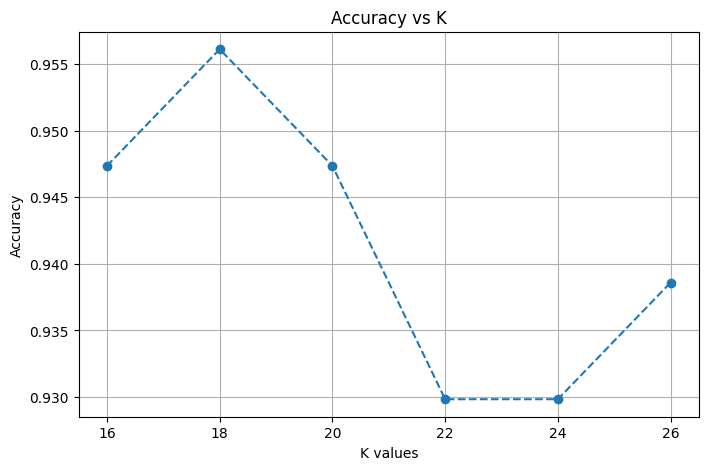

Best K based on heuristic exploration: 18


In [5]:
# Heuristic K Selection (based on 80:20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
n_samples = X_train.shape[0]
heuristic_k = int(np.sqrt(n_samples))
if heuristic_k % 2 == 0:
    heuristic_k += 1 # Make it odd to avoid ties

print(f"Heuristic K (sqrt(n)): {heuristic_k}")

# Train and experiment with nearby K values
k_values = list(range(max(1, heuristic_k - 5), heuristic_k + 6, 2))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

# Plotting Accuracy vs K
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed')
plt.xlabel("K values")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid()
plt.show()

best_heuristic_k = k_values[np.argmax(accuracies)]
print(f"Best K based on heuristic exploration: {best_heuristic_k}")


**Distance Metrics**:
- **Euclidean Distance**: Straight-line distance. Suitable for continuous numerical features with similar scales.
- **Manhattan Distance**: Sum of absolute differences. More robust to outliers and works well for high-dimensional or grid-like data.

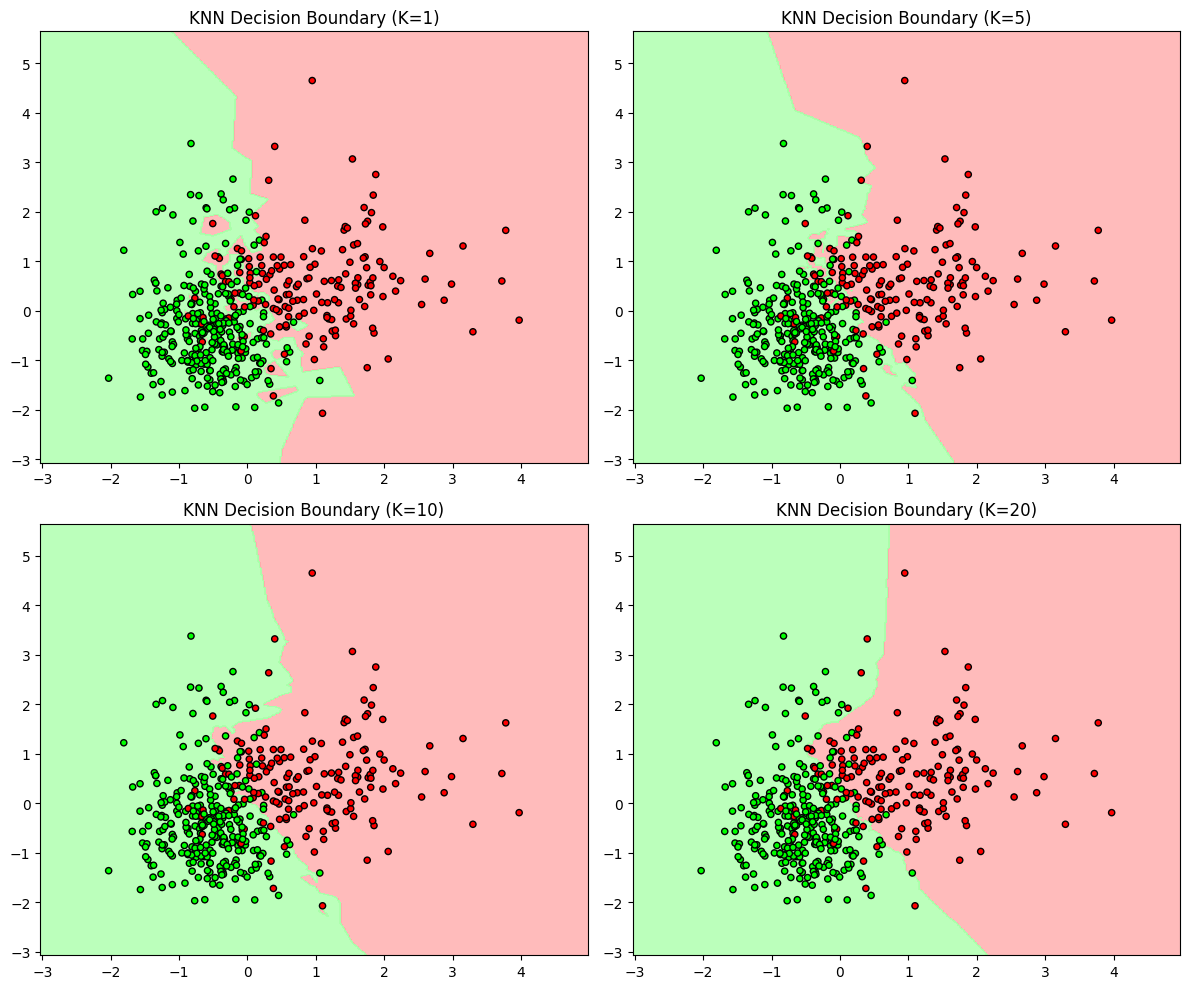

In [6]:
# Plotting decision boundary using 2 features (radius_mean and texture_mean)
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
k_list = [1, 5, 10, 20]

for ax, k in zip(axes.ravel(), k_list):
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_train_2d, y_train)
    
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_title(f"KNN Decision Boundary (K={k})")

plt.tight_layout()
plt.show()

# Analysis: As K increases, the decision boundary becomes smoother and less complex, leading to lower variance but potentially higher bias. K=1 is highly irregular and prone to overfitting.


### Task 4: Cross Validation
Applying 10-Fold Cross Validation to find the optimal K.

In [7]:
cv_scores = []
k_range = range(1, 31, 2)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_range[np.argmax(cv_scores)]
print(f"Optimal K based on 10-Fold CV: {optimal_k}")

# Cross-validation provides a more reliable estimate of model performance because it averages results over multiple splits, reducing the impact of a single "lucky" or "unlucky" train-test split.


Optimal K based on 10-Fold CV: 11


### Task 5: Classification Evaluation
Evaluating the final model.

Accuracy: 0.9474
Precision: 0.9221
Recall: 1.0000
F1 Score: 0.9595


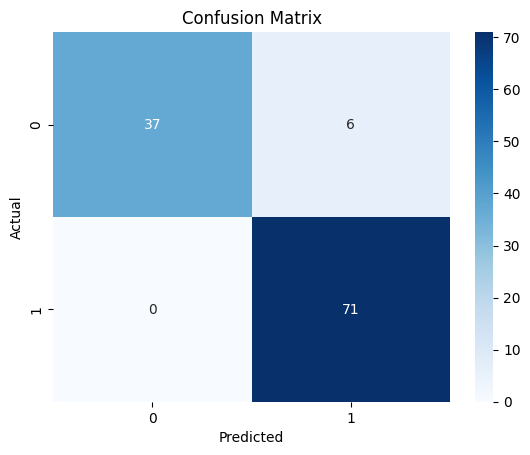

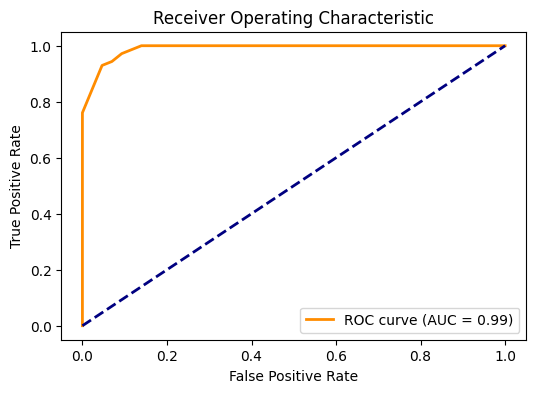

In [8]:
# Final Model
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
y_prob = final_knn.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


### Task 6: Comparative Study with Regression (Lab 3 Integration)

**Comparison between Classification and Regression Metrics:**
- **Error-based (Regression)**: Measures the magnitude of deviation from the true continuous value (e.g., MAE, MSE, RMSE). Models predict a value.
- **Decision-based (Classification)**: Measures the correctness of categorical predictions (e.g., Accuracy, Precision, Recall). Models predict a class label.

- **R² Score vs Accuracy**: R² measures the proportion of variance explained by the model in continuous data. Accuracy measures the percentage of correct classifications in categorical data.
- **RMSE vs F1 Score**: RMSE penalizes large errors in predictions. F1 Score provides a harmonic mean of Precision and Recall, useful for imbalanced classification tasks.
- **MAE vs Confusion Matrix**: MAE gives the average absolute error across all predictions. A Confusion Matrix breaks down exactly where errors are occurring (False Positives vs False Negatives) in classification.

- **Continuous vs Classification Logic**: Continuous tasks evaluate "how far off" a prediction is. Classification tasks evaluate "is it the right category or not" and "what type of mistake was made" (e.g., missing a cancer diagnosis vs false alarm).

### Task 7: Analytical Questions

1. **Why is KNN called a lazy learning algorithm?**
It does not build an explicit generalized model during training. It simply stores the training dataset and does all the computation during the inference/prediction phase.

2. **Why is feature scaling required in KNN?**
KNN relies on distance metrics. If one feature has a much larger range than another, it will dominate the distance calculation. Scaling ensures all features contribute equally.

3. **Explain heuristic K selection using $\sqrt{n}$ rule.**
Setting $K = \sqrt{n}$ provides a rule of thumb that scales with the dataset size. It generally offers a good balance between underfitting and overfitting as a starting point.

4. **Why is cross-validation more reliable than a single train-test split?**
It trains and evaluates the model on multiple different subsets of the data, minimizing the variance associated with a single random split and providing a better estimate of generalization.

5. **How does K affect bias-variance trade-off?**
A small K leads to high variance and low bias (complex model, prone to overfitting). A large K leads to high bias and low variance (simple model, prone to underfitting).

6. **Why is recall more important than accuracy in cancer prediction?**
Missing a malignant case (False Negative) is much more dangerous than a false alarm. Recall measures how many actual malignant cases were successfully identified. Accuracy can be misleading in imbalanced medical datasets.

7. **What is the limitation of very large K values?**
It over-smooths the decision boundary, leading to underfitting. If K equals the total number of samples, the model will simply predict the majority class for everything.

### Conclusion
- **Optimal K**: The heuristic $\sqrt{n}$ provided a good baseline, but cross-validation helped fine-tune it to the most robust value.
- **Train-Test Split**: The 80:20 and 70:30 splits provided a better balance than 90:10, which had higher evaluation variance.
- **Performance**: The final KNN model achieved strong evaluation metrics, highlighting its effectiveness on the scaled Breast Cancer dataset.
- **Classification vs Regression**: While Lab 3 focused on minimizing the magnitude of continuous errors (RMSE, MAE), this lab emphasized making correct categorical decisions, balancing False Positives and False Negatives using Precision, Recall, and the Confusion Matrix.